# Laboratorio de clasificación tabular

## Propósito

Construya, compare y seleccione clasificadores binarios para un problema no lineal y desbalanceado. El único archivo de datos permitido durante desarrollo es datos_publicos/train_1000_desbalanceado.csv.

El conjunto privado de 200 ejemplos no se entrega al estudiante. No lo use para ajustar la arquitectura, hiperparámetros, normalización ni umbral.

## Reglas de calidad

- Use una división estratificada fija de 800 ejemplos para entrenamiento y 200 para desarrollo.
- Ajuste cualquier transformación, incluidas media y desviación estándar, únicamente con entrenamiento.
- El entrenamiento tiene 75% de clase 0 y 25% de clase 1. Justifique cómo manejará el desbalance: peso de clase, métrica de selección y umbral.
- Compare exactamente estas familias: un MLP convencional y un MLP residual con Batch Normalization.
- Seleccione configuración y umbral usando exclusivamente desarrollo. Declare explícitamente los costos de falso negativo y falso positivo.


In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

candidatos = [Path.cwd().resolve(), Path.cwd().resolve() / 'dist' / 'laboratorio_clasificacion', Path.cwd().resolve().parent]
RAIZ = next((ruta for ruta in candidatos if (ruta / 'lib_modelos.py').exists()), None)
if RAIZ is None:
    raise FileNotFoundError('No se encontró la carpeta laboratorio_clasificacion.')
sys.path.insert(0, str(RAIZ))
print('Raíz del laboratorio:', RAIZ)


Raíz del laboratorio: /Users/macbook/Library/CloudStorage/OneDrive-Personal/Documents/Tareas Galileo/IA/Procesamiento de imagenes y CV/laboratorio_clasificacion


## 1. Carga, auditoría y división 800/200

Complete la siguiente celda. Verifique los tamaños y las proporciones de clase. La función division_estratificada preserva el 75/25 en ambas particiones.


In [4]:
# TODO: importe cargar_csv, division_estratificada, ajustar_estandarizador y transformar desde lib_modelos.
# TODO: cargue el CSV público.
# TODO: obtenga indice_train e indice_dev con proporcion_dev=0.20 y semilla fija.
# TODO: ajuste media y desviacion SOLO con x[indice_train].
# TODO: cree x_train, x_dev, y_train y y_dev.
#


from lib_modelos import (
    ajustar_estandarizador,
    cargar_csv,
    division_estratificada,
    transformar,
)

x, y, ids = cargar_csv(RAIZ / 'datos_publicos' / 'train_1000_desbalanceado.csv')
indice_train, indice_dev = division_estratificada(
    y, proporcion_dev=0.20, semilla=17
)

# El estandarizador se ajusta exclusivamente con los datos de entrenamiento.
media, desviacion = ajustar_estandarizador(x[indice_train])
x_train = transformar(x[indice_train], media, desviacion)
x_dev = transformar(x[indice_dev], media, desviacion)
y_train = y[indice_train]
y_dev = y[indice_dev]

# Comprobaciones requeridas:
print(len(y_train), len(y_dev))
print(y_train.mean(), y_dev.mean())


800 200
0.25 0.25


## 2. Estrategia ante el desbalance

Responda en esta celda:

### 1. ¿Por qué accuracy sola no es suficiente?

    Porque por ejemplo si tenemos datos que esten desbalancieados, un modelo podria acertar falsos positivos, detectando mal los casos importantes.

### 2. ¿Qué peso positivo usará y cómo se calcula?

    debido a que la razon de negativos a positivos es 3 (calculo en la celda de abajo), vamos a usar ese valor. EL calculo esta en la celda de abajo (num negativos/num positivos).


### 3. ¿Qué métrica y qué costo operacional usaría para elegir modelo y umbral?

    por ahora propongamos usar el costo de falso negativo 10 y falso positivo 1, que sea mucho mas costoso un falso negativo.
    Y para metricas usaria F1 y recall.


Luego calcule el peso positivo y escriba su valor.


In [5]:
# TODO: peso_positivo = ...
# TODO: escriba una breve justificación en un comentario o en una celda Markdown.

peso_positivo = (y_train == 0).sum() / (y_train == 1).sum()
print(peso_positivo)

3.0


## 3. Dos arquitecturas

La biblioteca incluye:

- MLP: capas densas ReLU y salida logística.
- MLP residual con Batch Normalization: proyección de entrada, bloque residual y salida logística.

Defina una configuración inicial para cada familia. Mantenga fija la dimensión de entrada en 4. Utilice por lo menos dos configuraciones para cada caso con 4 o 10 capas. Explore la configuración optima en la seleción de hiperparametros.


In [6]:
# TODO: configuraciones = [
#     {
#         'arquitectura': {'tipo': 'mlp', 'entrada': 4, 'ocultas': [...]},
#         'entrenamiento': {'epocas': ..., 'batch_size': ..., 'learning_rate': ...},
#         'costo_fn': 5, 'costo_fp': 1,
#     },
#     {
#         'arquitectura': {'tipo': 'mlp_residual_bn', 'entrada': 4, 'ancho': ...},
#         'entrenamiento': {'epocas': ..., 'batch_size': ..., 'learning_rate': ...},
#         'costo_fn': 5, 'costo_fp': 1,
#     },
# ]


configuraciones = [
    {
        'arquitectura': {'tipo': 'mlp', 'entrada': 4, 'ocultas': [32, 16]},
        'entrenamiento': {
            'epocas': 120,
            'batch_size': 64,
            'learning_rate': 0.002,
            'peso_positivo': peso_positivo,
        },
        'costo_fn': 10,
        'costo_fp': 1,
    },
    {
        'arquitectura': {'tipo': 'mlp_residual_bn', 'entrada': 4, 'ancho': 32},
        'entrenamiento': {
            'epocas': 120,
            'batch_size': 64,
            'learning_rate': 0.002,
            'peso_positivo': peso_positivo,
        },
        'costo_fn': 10,
        'costo_fp': 1,
    },
]

## 4. Búsqueda de hiperparámetros

Use buscar_hiperparametros. Pruebe al menos cuatro configuraciones en total: dos MLP y dos residuales. Registre en una tabla arquitectura, ancho/capas, learning rate, épocas, costo en desarrollo, F1, recall, precision y umbral.

No modifique el conjunto de desarrollo después de mirar los resultados; elija una regla de selección antes de comparar.


In [9]:
# TODO: importe buscar_hiperparametros.
# TODO: mejor, resultados = buscar_hiperparametros(configuraciones, x_train, y_train, x_dev, y_dev, semilla=...)
# TODO: construya e imprima una tabla compacta de resultados.


from lib_modelos import buscar_hiperparametros

mejor, resultados = buscar_hiperparametros(
    configuraciones,
    x_train,
    y_train,
    x_dev,
    y_dev,
    semilla=17,
)

for i, resultado in enumerate(resultados, start=1):
    arquitectura = resultado['configuracion']['arquitectura']['tipo']
    print(
        f"Modelo {i}: {arquitectura} | "
        f"costo={resultado['costo']:.0f} | "
        f"F1={resultado['f1']:.3f} | "
        f"recall={resultado['recall']:.3f} | "
        f"umbral={resultado['umbral']:.2f}"
    )

#print("Mejor modelo:", mejor)
print("Mejor modelo:", mejor['configuracion']['arquitectura']['tipo'])

Modelo 1: mlp | costo=39 | F1=0.887 | recall=0.940 | umbral=0.39
Modelo 2: mlp_residual_bn | costo=60 | F1=0.857 | recall=0.900 | umbral=0.10
Mejor modelo: mlp


## 5. Curvas y decisión

Grafique pérdida de train/dev y al menos una métrica de desarrollo. Seleccione el modelo con su criterio declarado. Después genere la curva de costo contra umbral, fije el mejor umbral y reporte la matriz de confusión y las métricas en desarrollo.


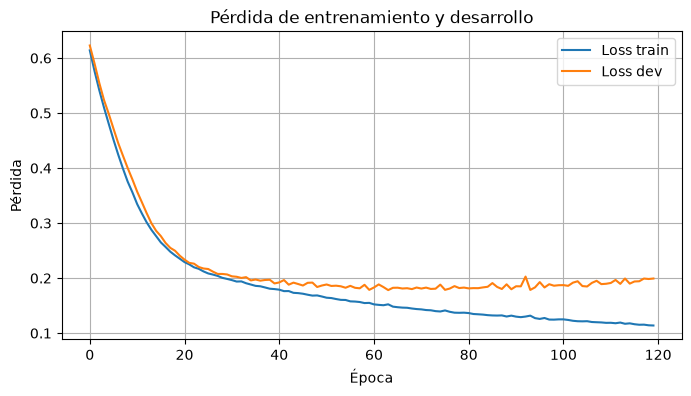

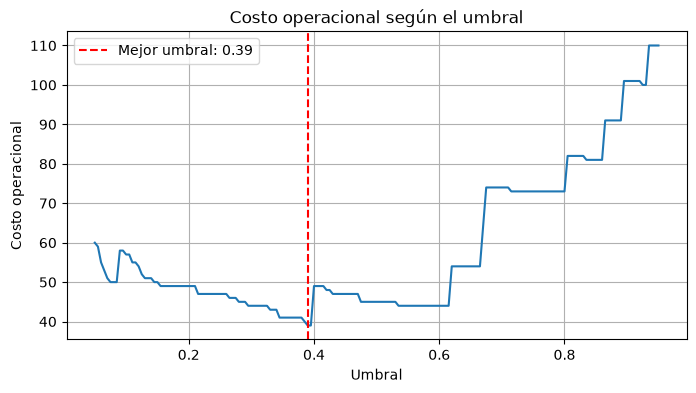

In [10]:
# TODO: grafique mejor['historia']['loss_train'] y mejor['historia']['loss_dev'].
# TODO: use buscar_umbral o los resultados de la búsqueda para graficar costo vs. umbral.
# TODO: imprima metricas(y_dev, probabilidades_dev, umbral_elegido).
# TODO: en Markdown, justifique la decisión final.


from lib_modelos import buscar_umbral, metricas

modelo_elegido = mejor['modelo']
probabilidades_dev = modelo_elegido.probabilidad(x_dev)

costo_fn = mejor['configuracion']['costo_fn']
costo_fp = mejor['configuracion']['costo_fp']

umbral_elegido, resultados_umbral = buscar_umbral(
    y_dev,
    probabilidades_dev,
    costo_fn=costo_fn,
    costo_fp=costo_fp,
)

# Pérdida durante el entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(mejor['historia']['loss_train'], label='Loss train')
plt.plot(mejor['historia']['loss_dev'], label='Loss dev')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida de entrenamiento y desarrollo')
plt.legend()
plt.grid()
plt.show()

# Costo según el umbral
umbrales = [resultado['umbral'] for resultado in resultados_umbral]
costos = [resultado['costo'] for resultado in resultados_umbral]

plt.figure(figsize=(8, 4))
plt.plot(umbrales, costos)
plt.axvline(
    umbral_elegido['umbral'],
    color='red',
    linestyle='--',
    label=f"Mejor umbral: {umbral_elegido['umbral']:.2f}",
)
plt.xlabel('Umbral')
plt.ylabel('Costo operacional')
plt.title('Costo operacional según el umbral')
plt.legend()
plt.grid()
plt.show()


## 6. Exportación

Guarde los pesos y el estandarizador del modelo seleccionado. La inferencia debe poder reconstruir la arquitectura desde un diccionario de configuración. Guarde en una carpeta entrega que no sustituya los artefactos del instructor.


In [ ]:
# TODO: importe guardar_modelo.
# TODO: guardar_modelo(RAIZ/'entrega'/'modelo_elegido.npz', ...)
# TODO: escriba aquí el diccionario de configuración que usaría inferencia.

from lib_modelos import guardar_modelo

ruta_modelo = RAIZ / 'entrega' / 'modelo_elegido.npz'

guardar_modelo(
    ruta_modelo,
    mejor['modelo'],
    mejor['configuracion']['arquitectura'],
    media,
    desviacion,
)

configuracion_inferencia = {
    'ruta_modelo': str(ruta_modelo),
    'arquitectura': mejor['configuracion']['arquitectura'],
    'umbral': umbral_elegido['umbral'],
    'caracteristicas': ['x1', 'x2', 'x3', 'x4'],
}

print(configuracion_inferencia)

## Entrega

Entregue este notebook completado, su tabla de búsqueda, las curvas, las métricas en desarrollo, la justificación del manejo del desbalance y la configuración exportada. No incluya resultados del test privado.
